# **Arvore de Decisao**

In [ ]:
# Se A verdadeiro: ramo 1 final
# Se A falso: ramo 2 com mais nos, etc

In [ ]:
# Progresso de construcao de Arvore
# Selecao de atributos (escolher o melhor atributo para dividir os dados)
# Divisao dos dados: dividir os dados com base no valor do atributo selecionado
# Construcao recursiva: repetir o processo nas subarvores criadas ate que os criterios de parada sejam atendidos

In [ ]:
## Criterios de selecao de atributos:
# Information Gain, Gini Index, Misclassification Error
# Information Gain busca ser maximizado
# Gini Index busca ser cada vez menor
# Misclassification Error, quanto menor o erro de classificacao, melhor a classificacao dos dados (0 a 1)

In [ ]:
## Vantagens da Arvore:
# Simplicidade e interpretabilidade, nao requer pre processamento intenso, lida com dados categoricos e numericos

# Desvantagens da Arvore:
# Tendencia ao overfitting (aprende coisas que impacta negativamente), sensivel a pequenas variacoes nos dados e dificuldade em lidar com problemas de alta dimensionalidade

In [ ]:
# Imports (Decision Tree - Sklearn)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay

from sklearn.tree import DecisionTreeClassifier # pode ser usado tanto pra classificacao, quanto regressao

In [ ]:
# Leitura de dados
df = pd.read_csv('diabetes.csv')
X = df.drop(columns=['Outcome'])
y = df['Outcome']

x_treino, x_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.3, random_state=101)

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
# Instanciando e treinamento de modelo de arvore
clf = DecisionTreeClassifier(random_state=101)
clf.fit(x_treino, y_treino)
pred = clf.predict(x_teste)

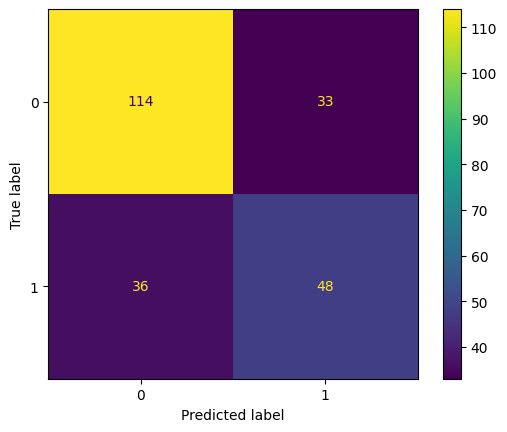

In [ ]:
# Avaliacao de modelo
matriz_confusao = confusion_matrix(pred, y_teste)
disp = ConfusionMatrixDisplay(confusion_matrix=matriz_confusao,
                              display_labels=clf.classes_)
disp.plot()

In [ ]:
# Calculo de Acuracia
accuracy_score(pred, y_teste)
# Ate o momento, a Decision Tree teve o pior desempenho de todos os modelos testados

0.7012987012987013

In [ ]:
# Calculo da acuracia do treino
accuracy_score(clf.predict(x_treino), y_treino)

# O modelo esta com overfitting: acertou e decorou todos os dados de treino, mas no teste, nao consegue realiza-lo bem.

1.0

In [ ]:
# Ajustes de parametros do modelo
# Criterion (gini, entropy, log_loss)
for criterion in ['gini', 'entropy', 'log_loss']:
  clf = DecisionTreeClassifier(criterion=criterion, random_state=101)
  clf.fit(x_treino, y_treino)
  pred = clf.predict(x_teste)
  print('Criterio:', criterion)
  print(accuracy_score(pred, y_teste), accuracy_score(clf.predict(x_treino), y_treino))
  print('='*100)

# O criterio de entropy e log_loss tiveram desempenho melhor que o de gini
# aparentemente, todos estao com overfitting ainda.

Criterio: gini
0.7012987012987013 1.0
Criterio: entropy
0.7748917748917749 1.0
Criterio: log_loss
0.7748917748917749 1.0


In [ ]:
# max_depth
# quantidade de nos que vai gerar antes de fazer as classificacoes
for max_depth in range(3, 10):
  clf = DecisionTreeClassifier(criterion='entropy', max_depth=max_depth, random_state=101)
  clf.fit(x_treino, y_treino)
  pred = clf.predict(x_teste)
  print('Max Depth:', max_depth)
  print(accuracy_score(pred, y_teste), accuracy_score(clf.predict(x_treino), y_treino))
  print('='*100)
  # a medida que o max_depth aumenta, a tendencia e diminuir a acuracia de teste, e aumentar a de treino
  # max_depth utilizada sera o 3

Max Depth: 3
0.7748917748917749 0.770949720670391
Max Depth: 4
0.7142857142857143 0.7839851024208566
Max Depth: 5
0.7186147186147186 0.8342644320297952
Max Depth: 6
0.7229437229437229 0.8621973929236499
Max Depth: 7
0.7489177489177489 0.8957169459962756
Max Depth: 8
0.7402597402597403 0.9385474860335196
Max Depth: 9
0.7532467532467533 0.9646182495344506


In [ ]:
# min_samples_split
# quantidade minima de amostrar necessarias para dividir um no (so divide se criterio for atendido)
for min_samples_split in range(2, 10, 2):
  clf = DecisionTreeClassifier(criterion='entropy',
                               max_depth=3,
                               min_samples_split=min_samples_split,
                               random_state=101)
  clf.fit(x_treino, y_treino)
  pred = clf.predict(x_teste)
  print('Min Samples Split:', min_samples_split)
  print(accuracy_score(pred, y_teste), accuracy_score(clf.predict(x_treino), y_treino))
  print('='*100)
  # aparentemente, nao houve mudanca alguma ao alterar o min_samples_split

Min Samples Split: 2
0.7748917748917749 0.770949720670391
Min Samples Split: 4
0.7748917748917749 0.770949720670391
Min Samples Split: 6
0.7748917748917749 0.770949720670391
Min Samples Split: 8
0.7748917748917749 0.770949720670391


In [ ]:
# min_samples_leaf (numero de amostrar para criar uma folha)
for min_samples_leaf in range(2, 10, 2):
  clf = DecisionTreeClassifier(criterion='entropy',
                              max_depth=3,
                              min_samples_leaf=min_samples_leaf,
                              random_state=101)
  clf.fit(x_treino,y_treino)
  pred = clf.predict(x_teste)
  print('Min Samples Leaf:', min_samples_leaf)
  print(accuracy_score(pred, y_teste), accuracy_score(clf.predict(x_treino), y_treino))
  print('='*100)
  # Tambem nao houve mudanca.

Min Samples Leaf: 2
0.7748917748917749 0.770949720670391
Min Samples Leaf: 4
0.7748917748917749 0.770949720670391
Min Samples Leaf: 6
0.7748917748917749 0.770949720670391
Min Samples Leaf: 8
0.7748917748917749 0.770949720670391


In [ ]:
# Geralmente, os parametros mais importantes para as Decision Tree sao os max_depth e criterion

In [ ]:
# Vizualiacao da Arvore de Decisao
clf = DecisionTreeClassifier(criterion='entropy',
                             max_depth=3,
                             random_state=101)
clf.fit(x_treino, y_treino)
pred = clf.predict(x_teste)
print(accuracy_score(pred, y_teste), accuracy_score(clf.predict(x_treino), y_treino))
print('='*100)

# Ate o momento, a maior acuracia encontrada foi de 77%.

0.7748917748917749 0.770949720670391


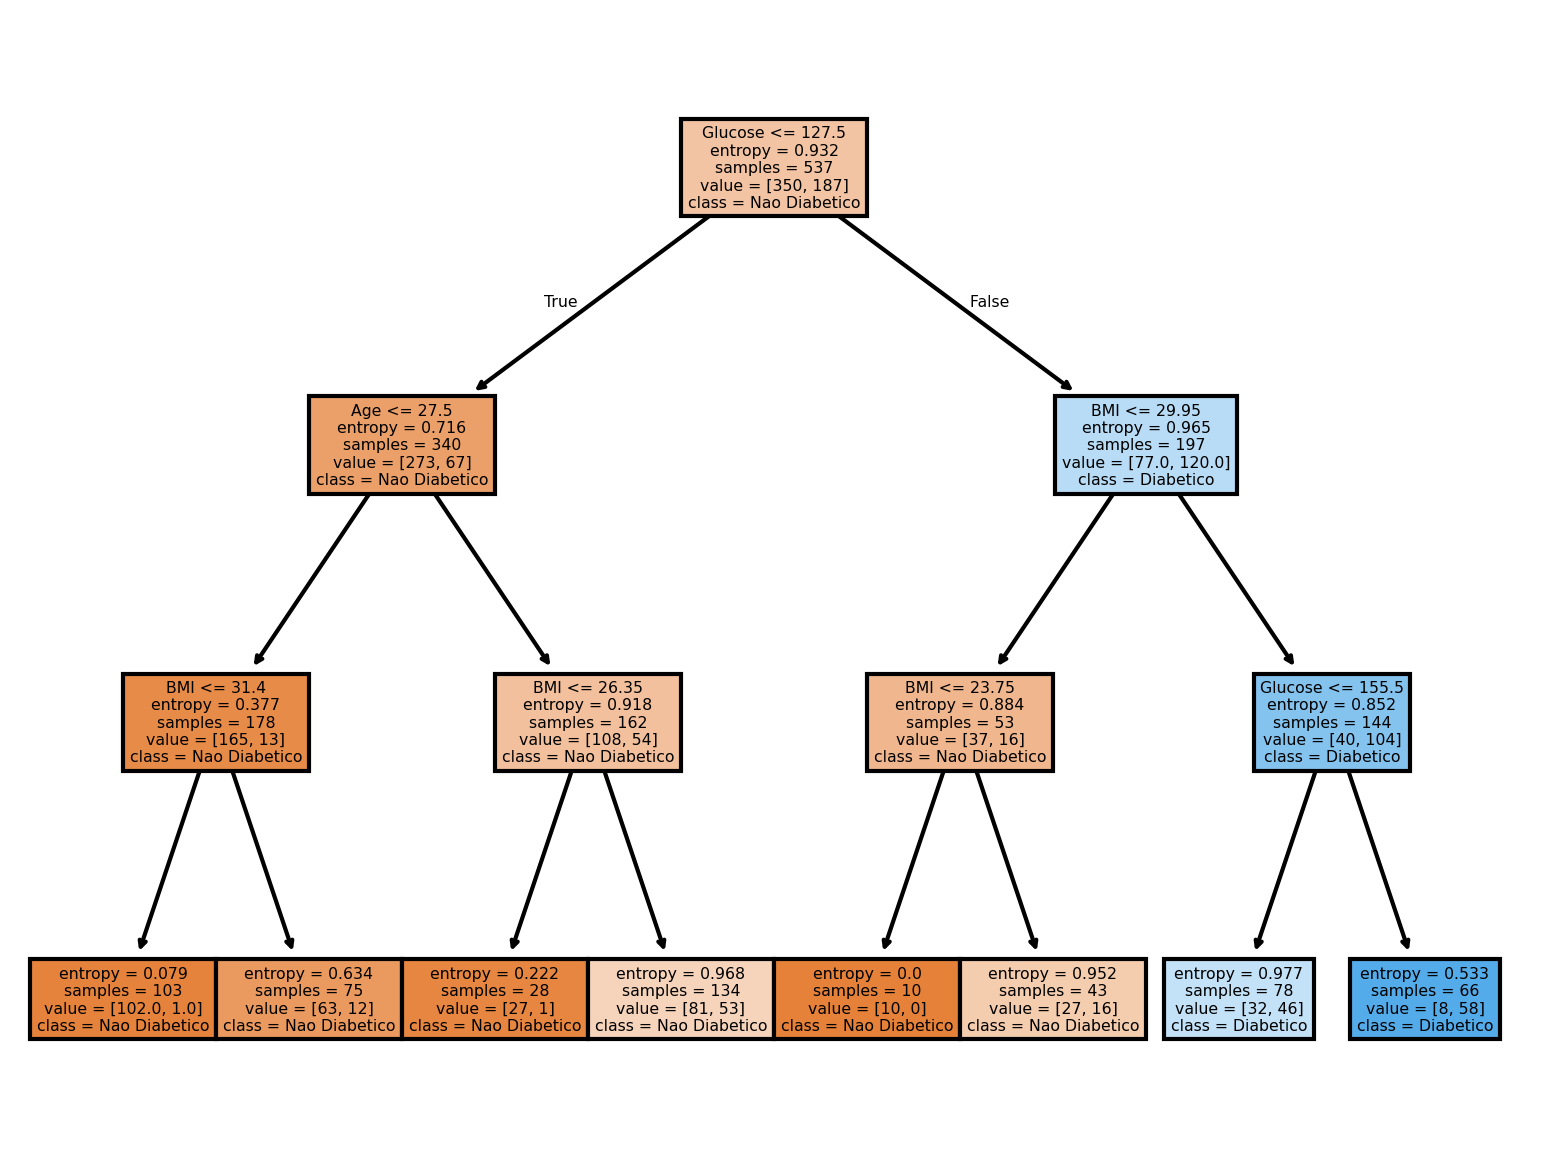

In [ ]:
# Vizualizacao da estrutura
from sklearn import tree

fig, ax = plt.subplots(1, dpi=300)

tree.plot_tree(clf, ax=ax,
               feature_names=x_treino.columns, # nome das features
               class_names=['Nao Diabetico', 'Diabetico'], # nome de classes
               filled=True); # figuras geradas serao coloridas
               # o ; no final evita varias mensagens de avisos

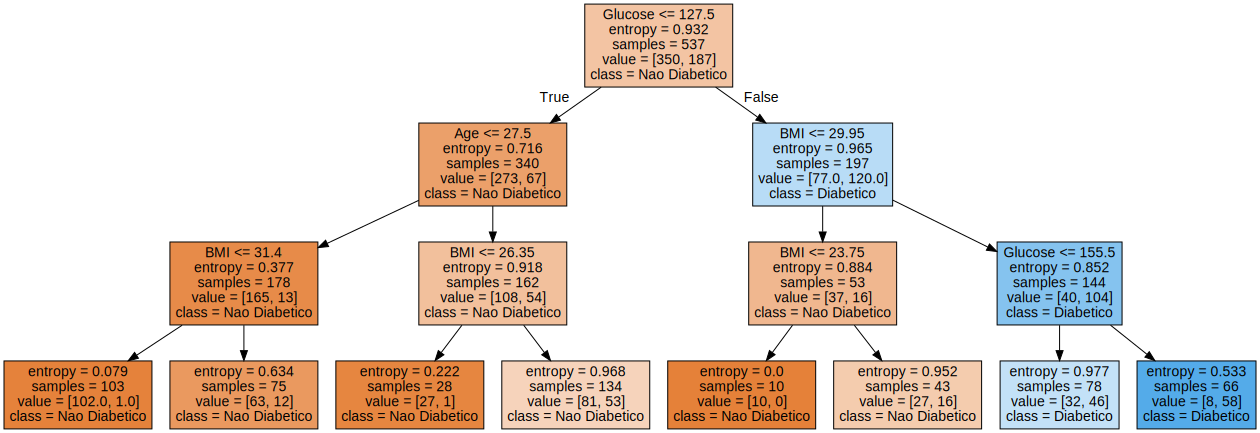

In [ ]:
# O graphviz permite uma vizualizacao em maior qualidade
import graphviz
dot_data = tree.export_graphviz(clf, out_file=None,
                                feature_names=x_treino.columns,
                                class_names=['Nao Diabetico', 'Diabetico'],
                                filled=True)
graph = graphviz.Source(dot_data, format='png')
graph